# This notebook shows how to apply the spin operators Sx, Sy, Sz to wavefunctions
### Import the necessary libraries

In [1]:
%matplotlib inline
import re
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure

### The spin operator
Elk's second-variational scheme reuses the SAME first-variational spatial orbitals for both spin channels, so the spin-up/spin-down blocks of `evecsv` alone determine the spin operator -- no muffin-tin integral needed, unlike the atom-projection operator:
$$ (S_z)_{mn}=\tfrac12(u_m^\dagger u_n - d_m^\dagger d_n), \quad (S_x)_{mn}=\tfrac12(u_m^\dagger d_n + d_m^\dagger u_n), \quad (S_y)_{mn}=\tfrac i2(d_m^\dagger u_n - u_m^\dagger d_n) $$
with $u_n,d_n$ the up/down row blocks of `evecsv`'s $n$-th column. $S_x,S_y,S_z$ are Hermitian, eigenvalues $\pm\tfrac12$.

In [2]:
# Bohr, monolayer 2H-WSe2 (a=3.32 Angstrom, thickness=3.34 Angstrom, 12 Angstrom vacuum --
# ase.build.mx2(formula="WSe2", kind="2H", a=3.32, thickness=3.34, vacuum=12) converted to Bohr)
A, C = 6.273890733757557, 51.66511224726855
WSE2_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, C)]
WSE2_SPECIES = {"W": [(0.0, 0.0, 0.5)], "Se": [(2 / 3, 1 / 3, 0.5610826627651793), (2 / 3, 1 / 3, 0.43891733723482085)]}

wse2 = Structure(WSE2_AVEC, WSE2_SPECIES).get_calculation(
    "_scratch/wse2_spin", xc="PW", ngridk=(3, 3, 1), rgkmax=7.0, spinorb=True
)
wse2.get_energy()  # spin-orbit coupling requires spinpol -- spinorb=True forces it internally

-21010.940270035

### Occupied-band count
From `EIGVAL.OUT`'s own occupation numbers, not an assumed electron count (`spinorb` forces `nspinor=2`, so Elk's own `occmax` is 1.0 per state here, not 2.0).

In [3]:
first_block = (wse2.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 0.5 for o in occ)  # valence-band-top index
ist1

60

### Spin-valley locking at K/K' in monolayer WSe2
Monolayer TMDs break inversion symmetry (unlike bulk 2H stacking); combined with strong spin-orbit coupling from the heavy W atom, this locks the valence-band-top spin to the valley index: $S_z(K)=-S_z(K')$ (Xiao, Liu, Feng, Xu & Yao, PRL 108, 196802 (2012)). The relative sign is that published prediction; the absolute sign is fixed by this structure's own conventions. Below, the same effect is shown as a full band structure colored by $\langle S_z\rangle$ (a spin texture), not just the two valence-top numbers.

In [4]:
K, Kprime = (1 / 3, 1 / 3, 0), (-1 / 3, -1 / 3, 0)
with wse2.eigenstate_session() as session:
    sz_k = session.spin_operator(K, ist1, ist1).sz[0, 0].real
    sz_kprime = session.spin_operator(Kprime, ist1, ist1).sz[0, 0].real
print("Sz(K) =", sz_k, " Sz(K') =", sz_kprime)

Sz(K) = -0.4996930868287473  Sz(K') = 0.4996930836020748


In [5]:
def segment(a, b, n):
    a, b = np.array(a), np.array(b)
    return [tuple(a + (b - a) * t) for t in np.linspace(0, 1, n)]

G, M = (0, 0, 0), (0.5, 0, 0)
# K' as the periodic image (2/3, -1/3, 0) -- same physical point as Kprime above,
# chosen here so the path hugs the BZ boundary the whole way instead of cutting
# through the interior near Gamma (same choice as 07_quantum_geometry.ipynb)
Kp = (2 / 3, -1 / 3, 0)
segments = [segment(G, K, 7)] + [segment(a, b, 7)[1:] for a, b in [(K, M), (M, Kp), (Kp, G)]]
ticks = np.concatenate([[0], np.cumsum([len(s) for s in segments]) - 1])
path = sum(segments, [])

w0, w1 = ist1 - 3, ist1 + 3  # same band window as the Hermiticity check above
efermi = float((wse2.workdir / "EFERMI.OUT").read_text().split()[0])
ha = 27.211386  # Hartree -> eV

energies, sz = [], []
with wse2.eigenstate_session() as session:
    for k in path:
        energies.append(session.get_eigenstates(k).energies[w0 - 1 : w1])
        sz.append(session.spin_operator(k, w0, w1).sz.diagonal().real)
energies = (np.array(energies) - efermi) * ha
sz = np.array(sz)

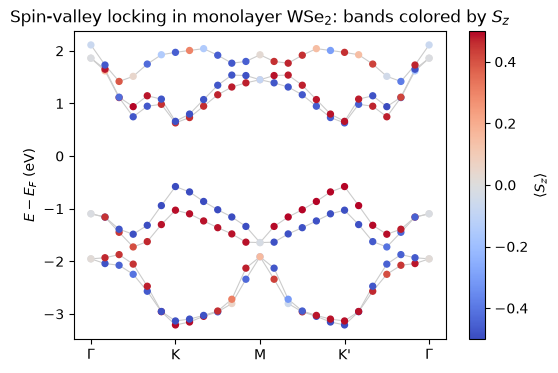

In [6]:
x = np.arange(len(path))
fig, ax = plt.subplots(figsize=(6, 4))
for band in range(energies.shape[1]):
    ax.plot(x, energies[:, band], color="0.8", linewidth=0.8, zorder=1)
sc = ax.scatter(
    np.tile(x, energies.shape[1]), energies.T.ravel(), c=sz.T.ravel(),
    cmap="coolwarm", vmin=-0.5, vmax=0.5, s=18, zorder=2,
)
ax.set_xticks(ticks)
ax.set_xticklabels([r"$\Gamma$", "K", "M", "K'", r"$\Gamma$"])
ax.set_ylabel(r"$E-E_F$ (eV)")
fig.colorbar(sc, ax=ax, label=r"$\langle S_z\rangle$")
ax.set_title("Spin-valley locking in monolayer WSe$_2$: bands colored by $S_z$")
plt.show()